# Phase 3 - Results and Evaluation (2026-04-22)

This notebook compares three models trained in Phases 1 and 2 - Logistic Regression, a Neural Network, and XGBoost - on the task of predicting whether a Lending Club loan will be fully repaid or will default. All three models were trained on the same preprocessed feature set from Phase 1 (accepted loans from 2007–2018, with leakage columns removed, categoricals one-hot encoded, and a chronological 70/30 train-test split) and evaluated on the same held-out test set of ~567,000 loans.

The key question is not just "which model is most accurate" - on an imbalanced dataset where ~87% of loans are non-defaults, a model that blindly predicts "non-default" every time would achieve 87% accuracy. Instead, we focus on metrics that capture how well each model distinguishes between good and bad borrowers: precision, recall, F1 score, and ROC AUC. We also sweep the decision threshold to understand the tradeoff each model offers between approving good borrowers (recall) and catching risky ones (specificity).

## 1. Import Libraries

In [ ]:
import pandas
import matplotlib.pyplot as plotter
import numpy as np
import seaborn as sns

## 2. Loading Data

In [ ]:
models = ['logistic_regression', 'neural_network', 'xgboost']
date = '2026-04-10'

summaries = []
thresholds = []

for model in models:
    summary_df = pandas.read_csv(f"results/{model}_{date}_summary.csv")
    summary_df = summary_df.set_index("metric").T
    summary_df["Model"] = model.replace("_", " ").title()
    summaries.append(summary_df)
    threshold_df = pandas.read_csv(f"results/{model}_{date}_thresholds.csv")
    threshold_df["Model"] = model.replace("_", " ").title()
    thresholds.append(threshold_df)

all_summaries_combined = pandas.concat(summaries, ignore_index=True)
all_thresholds_combined = pandas.concat(thresholds, ignore_index=True)

all_data = []
for _, row in all_summaries_combined.iterrows():
    for metric in ['accuracy', 'precision', 'recall', 'f1_score', 'roc_auc']:
        all_data.append({
            'Model': row['Model'],
            'Metric': metric,
            'Score': row[metric]
        })

all_data_df = pandas.DataFrame(all_data)
all_data_df['Score'] = pandas.to_numeric(all_data_df['Score'], errors='coerce')

## 3. Plotting Basic Model Evaluation Metrics

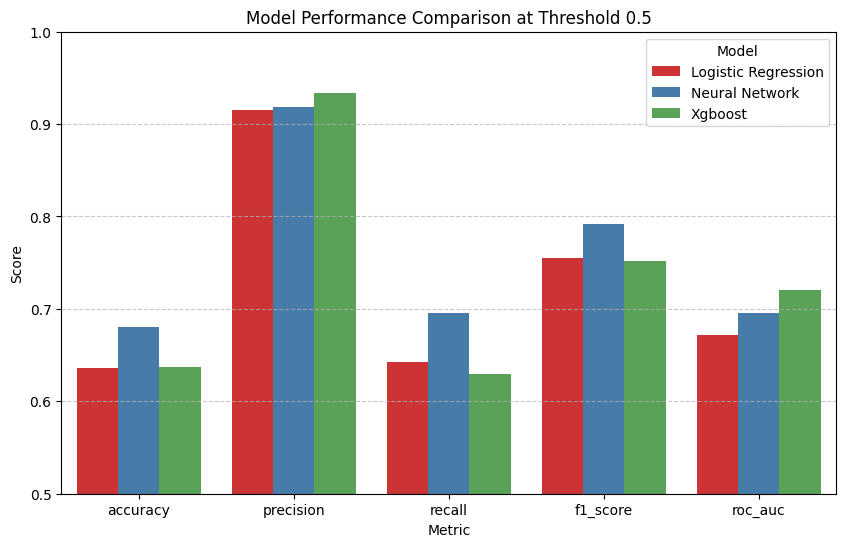

In [ ]:
plotter.figure(figsize=(10, 6))
sns.barplot(data=all_data_df, x='Metric', y='Score', hue='Model', palette='Set1')
plotter.title('Model Performance Comparison at Threshold 0.5')
plotter.ylim(0.5, 1.0)
plotter.grid(axis='y', linestyle='--', alpha=0.7)
plotter.show()

**Interpretation.** At the default threshold of 0.5, all three models show a similar pattern: very high precision (~91–93%) but moderate recall (~63-70%). This means that when a model predicts a loan will be fully repaid, it is right over 90% of the time - but it is also conservatively rejecting 30–37% of borrowers who would have actually repaid.

The Neural Network leads on recall (~70%) and F1 score (~0.79), meaning it identifies the most good borrowers while maintaining reasonable precision. XGBoost trades recall for the highest precision (~93%) - it is the most selective, approving fewer loans but with greater confidence that approved loans will be repaid. Logistic Regression falls between the two.

ROC AUC, which measures overall ranking ability independent of threshold, tells a similar story: XGBoost leads (~0.72), followed by Neural Network (~0.70), then Logistic Regression (~0.67). This suggests XGBoost produces the best-calibrated probability estimates even though its default-threshold recall is the lowest.

## 4. Plotting Precision-Recall Curve

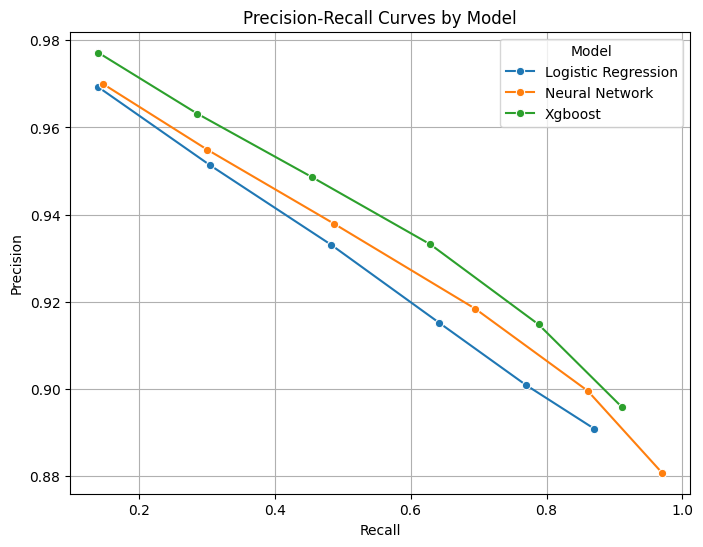

In [ ]:
plotter.figure(figsize=(8, 6))
sns.lineplot(data=all_thresholds_combined, x='recall', y='precision', hue='Model', marker='o')
plotter.title('Precision-Recall Curves by Model')
plotter.xlabel('Recall')
plotter.ylabel('Precision')
plotter.grid(True)
plotter.show()

**Interpretation.** The Precision-Recall curve shows the tradeoff each model faces as we adjust how aggressively it approves loans. The top-left corner (high precision, low recall) represents a conservative strategy - approve very few loans, but almost all of them will be repaid. The bottom-right (high recall, lower precision) represents a permissive strategy - approve most applicants, accepting that some defaults will slip through.

XGBoost (green) dominates the upper portion of the curve: at any given recall level, it maintains higher precision than the other two models. For example, at 50% recall, XGBoost holds ~95% precision while Logistic Regression drops to ~93%. This means if you're running a lending desk and want to keep your default rate below a specific target, XGBoost gives you the most room to approve loans without breaching that target.

The practical implication: XGBoost is the best model for a risk-averse investor who prioritizes avoiding defaults, while the Neural Network is better for a platform that wants to maximize loan volume while keeping precision above ~90%.

## 5. F-1 Score for different thresholds

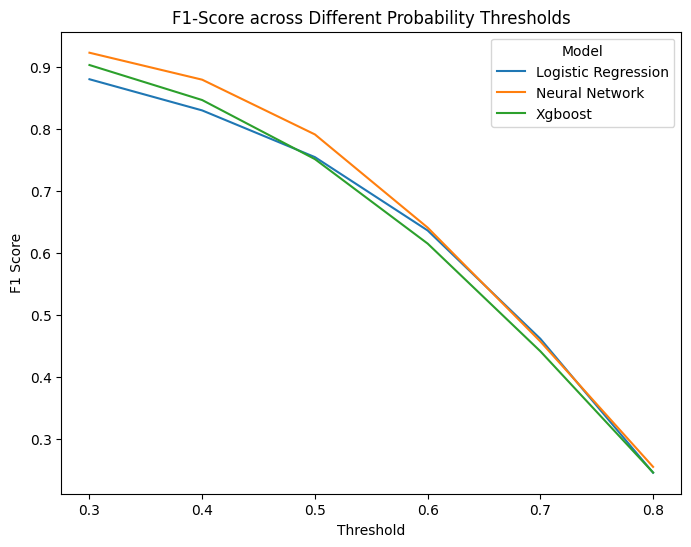

In [ ]:
plotter.figure(figsize=(8, 6))
sns.lineplot(data=all_thresholds_combined, x='threshold', y='f1_score', hue='Model')
plotter.title('F1-Score across Different Probability Thresholds')
plotter.ylabel('F1 Score')
plotter.xlabel('Threshold')
plotter.show()

**Interpretation.** The F1 score balances precision and recall into a single number. This plot shows how each model's F1 degrades as we raise the decision threshold (i.e., demand more confidence before approving a loan).

At low thresholds (0.3), the Neural Network leads with F1 ~0.92, meaning it achieves the best balance of catching good borrowers and avoiding bad ones in a permissive regime. As the threshold increases past 0.5, all three models converge and their F1 scores decline together - by threshold 0.7, all are below 0.5.

The key takeaway is that no model maintains strong F1 performance at high thresholds. This reflects the fundamental difficulty of the problem: the features available at loan origination (income, FICO score, credit history) provide moderate but not strong signal for predicting default. All three models extract roughly the same ceiling of predictive power from these features, just with slightly different tradeoff profiles.

## 6. Confusion Matrices

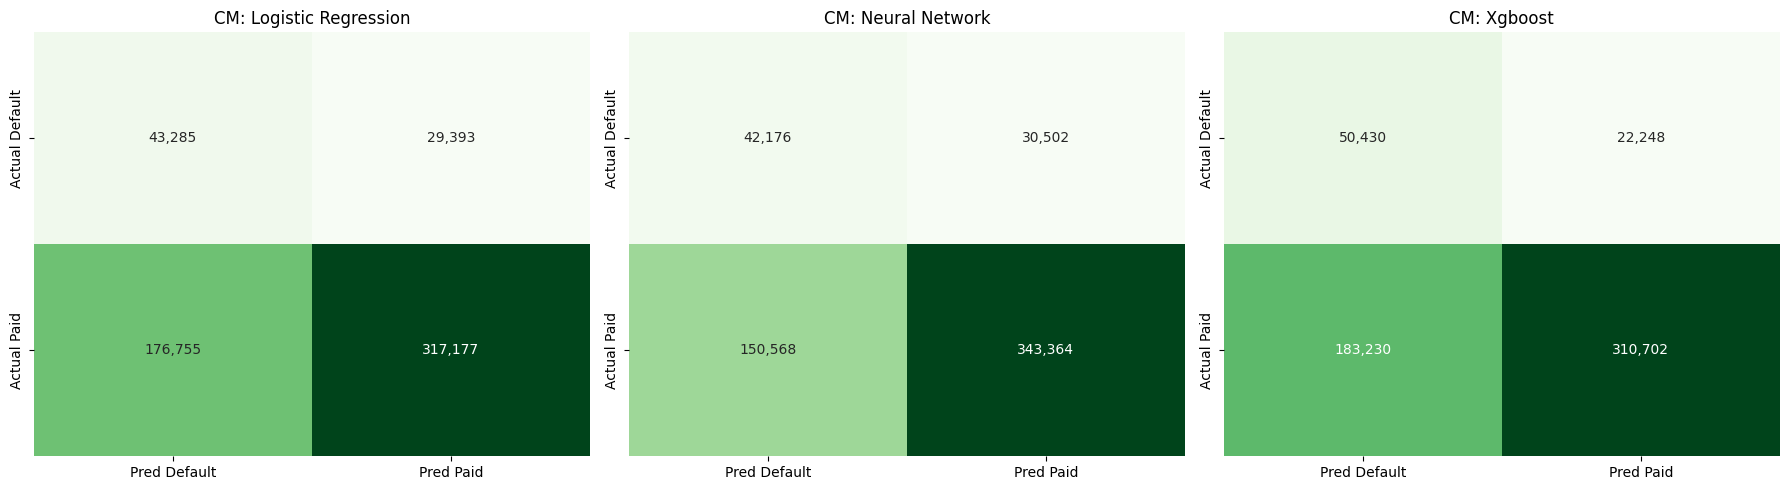

In [ ]:
fig, axes = plotter.subplots(1, 3, figsize=(18, 5))
for i, model in enumerate(models):
    df = pandas.read_csv(f"results/{model}_{date}_summary.csv").set_index('metric')
    matrix = np.array([[float(df.loc['tn', 'value']), float(df.loc['fp', 'value'])], 
                       [float(df.loc['fn', 'value']), float(df.loc['tp', 'value'])]])
    
    sns.heatmap(matrix, annot=True, fmt=',.0f', ax=axes[i], cmap='Greens', cbar=False)
    axes[i].set_title(f"CM: {model.replace('_', ' ').title()}")
    axes[i].set_xticklabels(['Pred Default', 'Pred Paid'])
    axes[i].set_yticklabels(['Actual Default', 'Actual Paid'])
plotter.tight_layout()

**Interpretation.** The confusion matrices reveal where each model's predictions concentrate.

Logistic Regression correctly identifies 43,285 defaults and 317,177 non-defaults, but misclassifies 176,755 good loans as defaults (false negatives). This is the cost of trying to catch defaults on an imbalanced dataset - the model becomes too cautious and flags many good borrowers.

The Neural Network has the most balanced profile: it catches slightly fewer defaults (42,176) but correctly approves 26,000 more good borrowers than Logistic Regression (343,364 vs 317,177), producing the fewest false negatives (150,568) of all three models.

XGBoost catches the most defaults of all three models (50,430 - roughly 69% of all actual defaults), but at the cost of the most false negatives (183,230 good loans flagged as risky). This is the "conservative lender" profile: XGBoost would reject more applicants overall, but the ones it does approve have the lowest default rate.

In dollar terms, the choice between models depends on whether missed defaults or rejected good borrowers cost more. If a single default wipes out the profit from several good loans (which is typical in lending), XGBoost's conservative approach may produce higher net returns despite approving fewer loans.

## 7. ROC AUC Curve

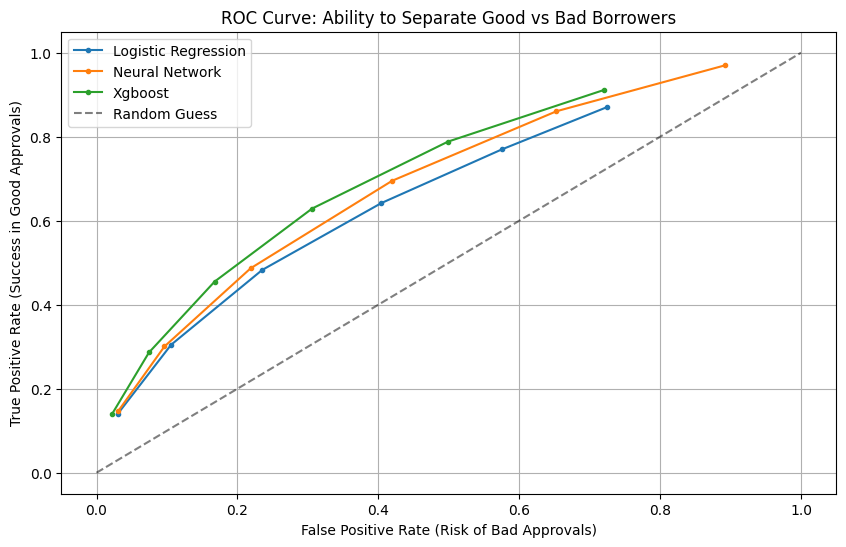

In [ ]:
plotter.figure(figsize=(10, 6))
for model in models:
    sub = all_thresholds_combined[all_thresholds_combined['Model'] == model.replace('_', ' ').title()]
    fpr = sub['fp'] / (sub['fp'] + sub['tn'])
    tpr = sub['recall']
    plotter.plot(fpr, tpr, marker='.', label=model.replace('_', ' ').title())

plotter.plot([0, 1], [0, 1], 'k--', alpha=0.5, label='Random Guess')
plotter.title('ROC Curve: Ability to Separate Good vs Bad Borrowers')
plotter.xlabel('False Positive Rate (Risk of Bad Approvals)')
plotter.ylabel('True Positive Rate (Success in Good Approvals)')
plotter.legend()
plotter.grid()
plotter.show()

**Interpretation.** The ROC curve plots each model's true positive rate (ability to correctly approve good borrowers) against its false positive rate (risk of approving bad borrowers) as the decision threshold varies. A model that perfectly separates defaults from non-defaults would hug the top-left corner; a random guess follows the diagonal.

All three curves track fairly close to each other, confirming that the models are extracting similar levels of signal from the feature set. XGBoost shows a slight edge in the middle portion of the curve (FPR 0.1-0.3), meaning it achieves higher true positive rates at moderate false positive rates - consistent with its AUC advantage.

The distance between all three curves and the top-left corner reflects the inherent difficulty of the prediction task. Loan defaults are driven partly by future events (job loss, medical emergencies, economic downturns) that cannot be captured by features available at origination. An AUC of ~0.67-0.72 means the models are meaningfully better than random but far from perfect - which is consistent with published results on similar Lending Club datasets when post-origination features and Lending Club's own grade assignments are excluded.

## Summary

Three models were evaluated on predicting Lending Club loan defaults using only pre-origination borrower features (no grade/subgrade, no post-funding payment history).

**Neural Network** achieved the best F1 score (0.79) and recall (69.5%), making it the strongest choice for maximizing loan approval volume while maintaining >90% precision. **XGBoost** achieved the highest ROC AUC (0.72) and specificity (69.4%), making it the best choice for risk-averse investment strategies that prioritize avoiding defaults. **Logistic Regression** performed between the two, with no clear advantage on any single metric.

All three models converge to similar performance ceilings, suggesting that the limiting factor is the feature set itself - not the model architecture. The origination-time features available in the Lending Club dataset provide moderate but not strong signal for default prediction. Future improvements would likely come from richer feature engineering (macroeconomic indicators, regional employment data) rather than from more complex models.

These results differ from the original CS229 paper (Chang et al., 2015-2016), which reported accuracy of 92-94% and G-mean of 85-87%. The likely explanation is a difference in label handling: the paper included `Current` loans (still being repaid, no known outcome) as positive examples, which inflated the positive class rate to ~87% and allowed models to achieve high accuracy by essentially predicting the majority class. Our pipeline excludes `Current` loans entirely, training and evaluating only on loans with resolved outcomes (Fully Paid vs Default/Charged Off/Late). This produces more honest - if less impressive - metrics that reflect genuine predictive ability rather than label contamination.